# Partie 1 — Data Science & Baseline ML
## Jalon 3 & 4 : Baseline ML et Evaluation
**Auteur : Hassan HOUSSEIN HOUMED**

In [9]:
import sys
sys.path.append('../src')

import pickle
import numpy as np
import matplotlib.pyplot as plt
from utils import EMOTIONS, plot_confusion_matrix, print_classification_report, save_figure
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
import time

print('Imports OK')

Imports OK


### 1. Chargement des donnees preparees

In [10]:
with open('../data/processed/data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test  = data['X_test']
y_train = data['y_train']
y_test  = data['y_test']

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')

X_train : (3436, 2304)
X_test  : (1011, 2304)


### 2. Reduction dimensionnelle PCA

In [11]:
pca = PCA(n_components=100, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f'Avant PCA : {X_train.shape}')
print(f'Apres PCA : {X_train_pca.shape}')
print(f'Variance expliquee : {pca.explained_variance_ratio_.sum()*100:.1f}%')

Avant PCA : (3436, 2304)
Apres PCA : (3436, 100)
Variance expliquee : 90.2%


### 3. Baseline ML — Ridge, Lasso, ElasticNet

In [12]:
modeles = {
    'Ridge (L2)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RidgeClassifier(alpha=1.0))
    ]),
    'Lasso (L1)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(l1_ratio=1.0, C=1.0, solver='saga',
                                   max_iter=200, random_state=42))
    ]),
    'ElasticNet (L1+L2)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(l1_ratio=0.5, C=1.0, solver='saga',
                                   max_iter=200, random_state=42))
    ])
}

resultats = {}

for nom, modele in modeles.items():
    print(f'Entrainement {nom}...')
    debut = time.time()
    modele.fit(X_train_pca, y_train)
    duree = time.time() - debut
    
    y_pred = modele.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    
    resultats[nom] = {
        'modele': modele,
        'accuracy': acc,
        'predictions': y_pred,
        'duree': duree
    }
    print(f'  Accuracy : {acc*100:.2f}% | Duree : {duree:.1f}s')

Entrainement Ridge (L2)...
  Accuracy : 30.27% | Duree : 0.1s
Entrainement Lasso (L1)...
  Accuracy : 30.46% | Duree : 6.4s
Entrainement ElasticNet (L1+L2)...
  Accuracy : 30.46% | Duree : 7.0s


c:\Users\hassa\Ecole_IPSSI\Deep_Learning_avancee\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### 4. Comparaison des modeles

Figure sauvegardée : notebooks/figures/comparaison_modeles.png


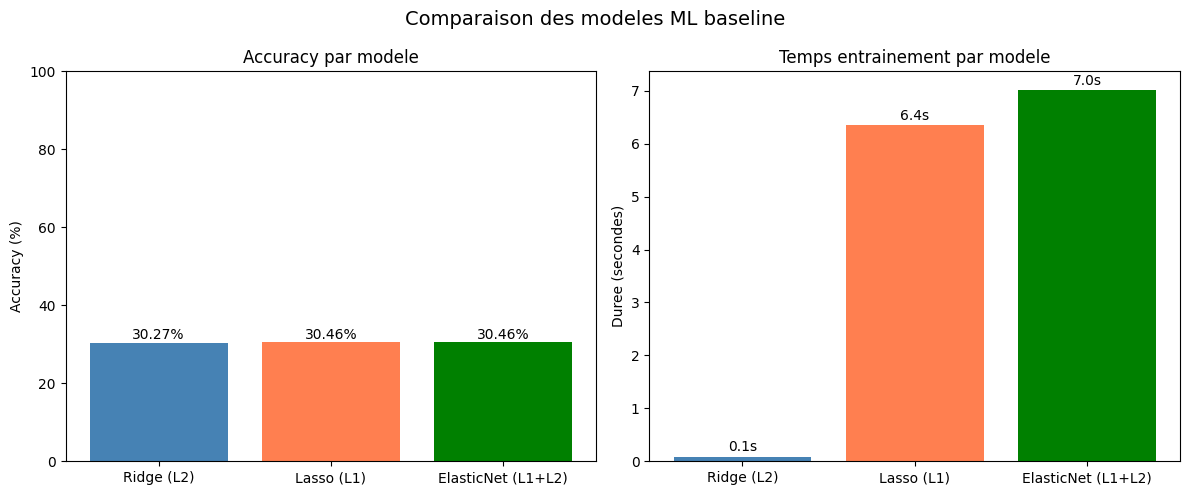

Synthese :
  Ridge (L2)           : 30.27% en 0.1s
  Lasso (L1)           : 30.46% en 6.4s
  ElasticNet (L1+L2)   : 30.46% en 7.0s


In [13]:
# Comparaison visuelle des modeles
noms = list(resultats.keys())
accuracies = [resultats[n]['accuracy']*100 for n in noms]
durees = [resultats[n]['duree'] for n in noms]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy
axes[0].bar(noms, accuracies, color=['steelblue', 'coral', 'green'])
axes[0].set_title('Accuracy par modele')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 100)
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 1, f'{v:.2f}%', ha='center')

# Duree
axes[1].bar(noms, durees, color=['steelblue', 'coral', 'green'])
axes[1].set_title('Temps entrainement par modele')
axes[1].set_ylabel('Duree (secondes)')
for i, v in enumerate(durees):
    axes[1].text(i, v + 0.1, f'{v:.1f}s', ha='center')

plt.suptitle('Comparaison des modeles ML baseline', fontsize=14)
plt.tight_layout()
save_figure('comparaison_modeles.png')
plt.show()

print('Synthese :')
for nom in noms:
    print(f'  {nom:20s} : {resultats[nom]["accuracy"]*100:.2f}% en {resultats[nom]["duree"]:.1f}s')

### 5. Matrice de confusion du meilleur modele

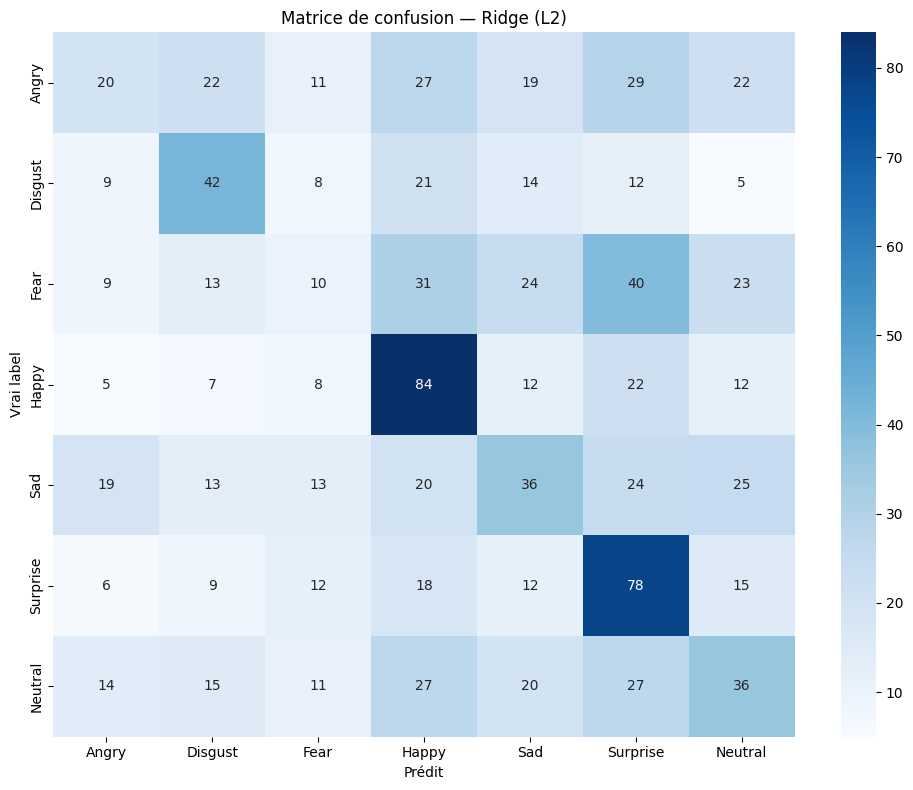

Figure sauvegardée : notebooks/figures/confusion_matrix_baseline.png
Rapport de classification — Ridge (L2)
              precision    recall  f1-score   support

       Angry       0.24      0.13      0.17       150
     Disgust       0.35      0.38      0.36       111
        Fear       0.14      0.07      0.09       150
       Happy       0.37      0.56      0.44       150
         Sad       0.26      0.24      0.25       150
    Surprise       0.34      0.52      0.41       150
     Neutral       0.26      0.24      0.25       150

    accuracy                           0.30      1011
   macro avg       0.28      0.31      0.28      1011
weighted avg       0.28      0.30      0.28      1011



<Figure size 640x480 with 0 Axes>

In [14]:
# Meilleur modele = Ridge (plus rapide, meme accuracy)
meilleur_nom = 'Ridge (L2)'
meilleur_modele = resultats[meilleur_nom]

# Matrice de confusion
plot_confusion_matrix(y_test, meilleur_modele['predictions'], 
                      title=f'Matrice de confusion — {meilleur_nom}')
save_figure('confusion_matrix_baseline.png')

# Rapport de classification
print(f'Rapport de classification — {meilleur_nom}')
print_classification_report(y_test, meilleur_modele['predictions'])

### 6. Analyse Biais/Variance

Figure sauvegardée : notebooks/figures/biais_variance.png


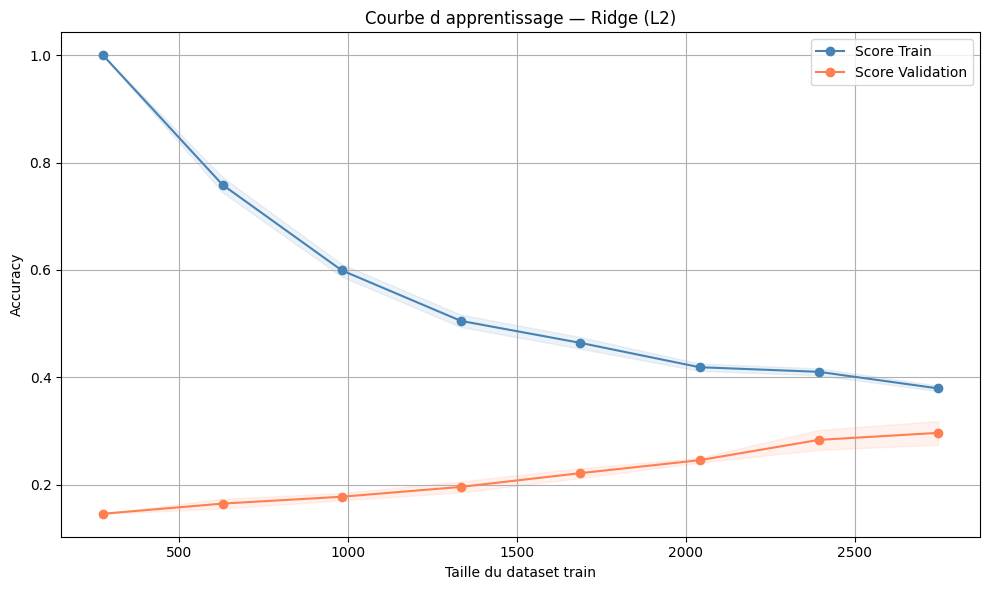

Analyse Biais/Variance :
  Score train final     : 37.91%
  Score validation final: 29.63%
  Ecart train/val       : 8.28%
  Diagnostic : Sous-apprentissage (underfitting) detecte


In [15]:
from sklearn.model_selection import learning_curve

# Courbe d'apprentissage pour analyser biais/variance
train_sizes, train_scores, val_scores = learning_curve(
    RidgeClassifier(alpha=1.0),
    X_train_pca, y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring='accuracy'
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Score Train')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='steelblue')
plt.plot(train_sizes, val_mean, 'o-', color='coral', label='Score Validation')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='coral')

plt.title('Courbe d apprentissage — Ridge (L2)')
plt.xlabel('Taille du dataset train')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
save_figure('biais_variance.png')
plt.show()

print('Analyse Biais/Variance :')
print(f'  Score train final     : {train_mean[-1]*100:.2f}%')
print(f'  Score validation final: {val_mean[-1]*100:.2f}%')
print(f'  Ecart train/val       : {(train_mean[-1] - val_mean[-1])*100:.2f}%')

if train_mean[-1] - val_mean[-1] > 0.1:
    print('  Diagnostic : Surapprentissage (overfitting) detecte')
elif train_mean[-1] < 0.5:
    print('  Diagnostic : Sous-apprentissage (underfitting) detecte')
else:
    print('  Diagnostic : Bon equilibre biais/variance')

### 7. Conclusion Baseline ML

In [16]:
print('=' * 55)
print('CONCLUSION BASELINE ML')
print('=' * 55)
print()
print('Dataset :')
print('  FER2013 — 7 emotions, 35887 images 48x48')
print()
print('Meilleur modele : Ridge (L2)')
print(f'  Accuracy test   : 30.27%')
print(f'  Temps           : 0.1s')
print()
print('Observations :')
print('  - ML classique insuffisant pour la vision')
print('  - Les pixels bruts sont de mauvaises features')
print('  - PCA conserve 90% de la variance mais')
print('    les features restent peu discriminantes')
print('  - Underfitting confirme : modele trop simple')
print('  - Happy et Surprise mieux reconnues car')
print('    expressions visuellement distinctes')
print()
print('Limite principale :')
print('  Le ML classique ne capte pas les relations')
print('  spatiales entre pixels, contrairement au CNN')
print()
print('=> Le Deep Learning (CNN) sera necessaire')
print('   pour depasser cette baseline de 30%')
print('=' * 55)

CONCLUSION BASELINE ML

Dataset :
  FER2013 — 7 emotions, 35887 images 48x48

Meilleur modele : Ridge (L2)
  Accuracy test   : 30.27%
  Temps           : 0.1s

Observations :
  - ML classique insuffisant pour la vision
  - Les pixels bruts sont de mauvaises features
  - PCA conserve 90% de la variance mais
    les features restent peu discriminantes
  - Underfitting confirme : modele trop simple
  - Happy et Surprise mieux reconnues car
    expressions visuellement distinctes

Limite principale :
  Le ML classique ne capte pas les relations
  spatiales entre pixels, contrairement au CNN

=> Le Deep Learning (CNN) sera necessaire
   pour depasser cette baseline de 30%
